In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
prices_d1 = pd.read_csv("/Users/rishikbalerao/Desktop/prosperity_tutorial/prices_round_0_day_-1.csv", sep=";")
prices_d2 = pd.read_csv("/Users/rishikbalerao/Desktop/prosperity_tutorial/prices_round_0_day_-2.csv", sep=";")
trades_d1 = pd.read_csv("/Users/rishikbalerao/Desktop/prosperity_tutorial/trades_round_0_day_-1.csv", sep=";")
trades_d2 = pd.read_csv("/Users/rishikbalerao/Desktop/prosperity_tutorial/trades_round_0_day_-2.csv", sep=";")

In [3]:
prices_d1.head(10)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,14,9990,29,NaN,NaN,10008,14,10010,29,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,11,9990,22,NaN,NaN,10008,11,10010,22,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
5,-1,200,TOMATOES,5000,10,4999,20,NaN,NaN,5013,10,5015,20,NaN,NaN,5006.5,0.0
6,-1,300,TOMATOES,5000,9,4999,21,NaN,NaN,5014,9,5015,21,NaN,NaN,5007.0,0.0
7,-1,300,EMERALDS,9992,11,9990,29,NaN,NaN,10008,11,10010,29,NaN,NaN,10000.0,0.0
8,-1,400,TOMATOES,5000,5,4999,20,NaN,NaN,5014,5,5015,20,NaN,NaN,5007.0,0.0
9,-1,400,EMERALDS,9992,12,9990,25,NaN,NaN,10008,12,10010,25,NaN,NaN,10000.0,0.0


In [4]:
emerald_price_d1 = prices_d1.query("product == 'EMERALDS'")

In [5]:
tomato_price_d1 = prices_d1.query("product == 'TOMATOES'")

In [6]:
tomato_price_d1

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,5,4998,15,NaN,NaN,5013,5,5014,15,NaN,NaN,5006.0,0.0
3,-1,100,TOMATOES,5000,8,4998,21,NaN,NaN,5013,8,5014,21,NaN,NaN,5006.5,0.0
5,-1,200,TOMATOES,5000,10,4999,20,NaN,NaN,5013,10,5015,20,NaN,NaN,5006.5,0.0
6,-1,300,TOMATOES,5000,9,4999,21,NaN,NaN,5014,9,5015,21,NaN,NaN,5007.0,0.0
8,-1,400,TOMATOES,5000,5,4999,20,NaN,NaN,5014,5,5015,20,NaN,NaN,5007.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19990,-1,999500,TOMATOES,4955,5,4950,10,4948.0,23.0,4963,10,4964,23,NaN,NaN,4959.0,0.0
19993,-1,999600,TOMATOES,4955,5,4949,6,4948.0,18.0,4963,6,4964,18,NaN,NaN,4959.0,0.0
19994,-1,999700,TOMATOES,4950,10,4948,16,NaN,NaN,4963,10,4964,16,NaN,NaN,4956.5,0.0
19997,-1,999800,TOMATOES,4951,6,4949,18,NaN,NaN,4964,6,4965,18,NaN,NaN,4957.5,0.0


In [7]:
trades_d1.head(20)

,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
1,3400,NaN,NaN,TOMATOES,XIRECS,5009.0,2
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
3,7000,NaN,NaN,TOMATOES,XIRECS,5010.0,4
4,9600,NaN,NaN,TOMATOES,XIRECS,4999.0,5
5,9900,NaN,NaN,TOMATOES,XIRECS,5000.0,4
6,16400,NaN,NaN,TOMATOES,XIRECS,4996.0,2
7,17900,NaN,NaN,TOMATOES,XIRECS,5009.0,2
8,22200,NaN,NaN,TOMATOES,XIRECS,5005.0,3
9,23500,NaN,NaN,TOMATOES,XIRECS,4989.0,3


In [8]:
tomato_trades_d1 = trades_d1.query("symbol == 'TOMATOES'")
emerald_trades_d1 = trades_d1.query("symbol == 'EMERALDS'")

In [9]:
import plotly.graph_objects as go

def plot_interval(order_book, trades, t0, t1):
    curr_order_book = order_book.iloc[t0:t1]
    idx = curr_order_book["timestamp"]

    t_min = idx.min()
    t_max = idx.max()

    # filter trades to same time window
    curr_trades = trades[
        (trades["timestamp"] >= t_min) &
        (trades["timestamp"] <= t_max)
    ]

    fig = go.Figure()

    # --- mid ---
    fig.add_trace(go.Scatter(
        x=idx, y=curr_order_book["mid_price"],
        name="mid",
        line=dict(width=3)
    ))

    # --- bids ---
    for i in range(1, 4):
        fig.add_trace(go.Scatter(
            x=idx,
            y=curr_order_book[f"bid_price_{i}"],
            name=f"bid_price_{i}",
            customdata=curr_order_book[[f"bid_volume_{i}"]],
            hovertemplate=
                f"Bid Level {i}<br>" +
                "Price: %{y}<br>" +
                "Volume: %{customdata[0]}<br>" +
                "Time: %{x}<extra></extra>"
        ))

    # --- asks ---
    for i in range(1, 4):
        fig.add_trace(go.Scatter(
            x=idx,
            y=curr_order_book[f"ask_price_{i}"],
            name=f"ask_price_{i}",
            customdata=curr_order_book[[f"ask_volume_{i}"]],
            hovertemplate=
                f"Ask Level {i}<br>" +
                "Price: %{y}<br>" +
                "Volume: %{customdata[0]}<br>" +
                "Time: %{x}<extra></extra>"
        ))

    # --- trades ---
    # --- trades ---
    if not curr_trades.empty:
        mid_series = curr_order_book.set_index("timestamp")["mid_price"]

        # align mid prices to trade timestamps (positional)
        trade_mid = mid_series.reindex(curr_trades["timestamp"], method="nearest").to_numpy()

        trade_prices = curr_trades["price"].to_numpy()

        # infer direction
        colors = ["green" if p > m else "red" for p, m in zip(trade_prices, trade_mid)]

        # scale sizes
        sizes = curr_trades["quantity"].to_numpy()
        sizes = 5 + 15 * (sizes / sizes.max())

        fig.add_trace(go.Scatter(
            x=curr_trades["timestamp"],
            y=curr_trades["price"],
            mode="markers",
            name="trades",
            customdata=curr_trades["quantity"],
            marker=dict(
                size=sizes,
                color=colors,
                opacity=0.6,
                line=dict(width=1)
            ),
            hovertemplate=
                "Price: %{y}<br>" +
                "Quantity: %{customdata}<br>" +
                "Time: %{x}<extra></extra>"
        ))

    fig.update_layout(
        title="orderbook + trades (size encoded)",
        xaxis_title="timestamp",
        yaxis_title="price",
        legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
        margin=dict(r=150)
    )

    fig.show()

    # --- spread plot ---
    spread_fig = go.Figure()
    spread = curr_order_book["ask_price_1"] - curr_order_book["bid_price_1"]

    spread_fig.add_trace(go.Scatter(
        x=idx, y=spread,
        name="bid-ask spread",
        line=dict(width=2)
    ))

    spread_fig.update_layout(
        title="bid-ask spread over interval",
        xaxis_title="timestamp",
        yaxis_title="spread"
    )

    spread_fig.show()

In [10]:
plot_interval(emerald_price_d1, emerald_trades_d1, 0, 8000)

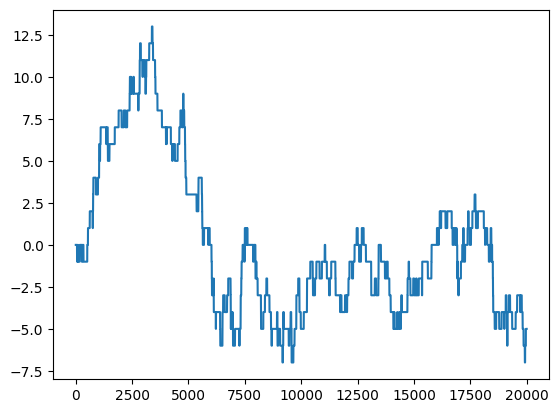

In [11]:
is_ask_spike = emerald_price_d1["ask_price_1"] < 10008
is_bid_spike = emerald_price_d1["bid_price_1"] > 9992
all_spikes = is_bid_spike +  -1*is_ask_spike
plt.plot(all_spikes.cumsum())

In [12]:
all_spikes = all_spikes[all_spikes != 0].reset_index(drop=True)

In [13]:
spikes_df = pd.DataFrame(all_spikes)

In [14]:
spikes_df["next"] = all_spikes.shift(-1)

In [15]:
spikes_df = spikes_df.rename(columns={
    0 : "curr"
})

In [16]:
spikes_df

,curr,next
0,-1,1.0
1,1,-1.0
2,-1,1.0
3,1,-1.0
4,-1,1.0
...,...,...
316,-1,-1.0
317,-1,-1.0
318,-1,1.0
319,1,1.0


In [17]:
spikes_df = spikes_df.dropna()
counts = pd.crosstab(spikes_df["curr"], spikes_df["next"])

# ensure both states exist in rows/columns
states = [-1, 1]
counts = counts.reindex(index=states, columns=states)

# normalize rows to get conditional probabilities
transition_matrix = counts.div(counts.sum(axis=1), axis=0)

print(transition_matrix)

next        -1         1
curr                    
-1    0.478528  0.521472
 1    0.535032  0.464968


In [18]:
spikes_df["curr"].autocorr(lag=1)

np.float64(-0.05992686133474977)

In [19]:
emerald_trades_d1.head(10)

,timestamp,buyer,seller,symbol,currency,price,quantity
0,3200,NaN,NaN,EMERALDS,XIRECS,9992.0,8
2,5000,NaN,NaN,EMERALDS,XIRECS,9992.0,7
12,31400,NaN,NaN,EMERALDS,XIRECS,10008.0,3
17,39900,NaN,NaN,EMERALDS,XIRECS,9992.0,7
18,42400,NaN,NaN,EMERALDS,XIRECS,9992.0,5
20,51300,NaN,NaN,EMERALDS,XIRECS,9992.0,7
25,55300,NaN,NaN,EMERALDS,XIRECS,9992.0,6
26,55700,NaN,NaN,EMERALDS,XIRECS,9992.0,4
28,62700,NaN,NaN,EMERALDS,XIRECS,9992.0,8
31,66700,NaN,NaN,EMERALDS,XIRECS,10008.0,7


In [20]:
emerald_trades_sides = emerald_trades_d1[["price", "quantity"]].query("price != 10000")

In [21]:
emerald_trades_sides["buy"] = (emerald_trades_sides["price"] == 9992)

In [22]:
emerald_trades_sides["buy"] = emerald_trades_sides["buy"]*2 - 1

In [23]:
emerald_trades_sides["signed_vol"] = emerald_trades_sides["quantity"] * emerald_trades_sides["buy"]

In [24]:
emerald_trades_sides["signed_vol"]

0      8
2      7
12    -3
17     7
18     5
      ..
620   -8
623   -6
625   -6
626   -3
628   -6
Name: signed_vol, Length: 200, dtype: int64

In [25]:
for i in range(1, 20):
    print(f"autocorrelation for lag {i} is {emerald_trades_sides["signed_vol"].autocorr(i)}")

autocorrelation for lag 1 is -0.03700268753187701
autocorrelation for lag 2 is -0.005509642408926911
autocorrelation for lag 3 is 0.047942532796661684
autocorrelation for lag 4 is 0.015160453695398687
autocorrelation for lag 5 is 0.09148242253737121
autocorrelation for lag 6 is 0.07625349503524856
autocorrelation for lag 7 is -0.06737824708779311
autocorrelation for lag 8 is -0.021707172993896084
autocorrelation for lag 9 is 0.03785168294903361
autocorrelation for lag 10 is 0.12695934339195594
autocorrelation for lag 11 is -0.004280643996984712
autocorrelation for lag 12 is -0.07951503498059652
autocorrelation for lag 13 is 0.06713171763333144
autocorrelation for lag 14 is -0.1468014410886058
autocorrelation for lag 15 is 0.08547265671709599
autocorrelation for lag 16 is 0.02796087152234573
autocorrelation for lag 17 is 0.009157164784881915
autocorrelation for lag 18 is -0.03550400362920653
autocorrelation for lag 19 is -0.09579586663420481


In [26]:
for i in range(1, 20):
    print(f"autocorrelation for lag {i} is {emerald_trades_sides["buy"].autocorr(i)}")

autocorrelation for lag 1 is -0.03525608665327711
autocorrelation for lag 2 is -0.01010307195245044
autocorrelation for lag 3 is 0.06588308388158258
autocorrelation for lag 4 is 0.010208866166750865
autocorrelation for lag 5 is 0.09768423000904508
autocorrelation for lag 6 is 0.07252233748350571
autocorrelation for lag 7 is -0.08758733129088202
autocorrelation for lag 8 is 0.0008689986638178395
autocorrelation for lag 9 is 0.10053781688689278
autocorrelation for lag 10 is 0.09572936119136735
autocorrelation for lag 11 is 0.006277323524992299
autocorrelation for lag 12 is -0.09452032250389059
autocorrelation for lag 13 is 0.04959908361970217
autocorrelation for lag 14 is -0.18128113054558093
autocorrelation for lag 15 is 0.08364573570759135
autocorrelation for lag 16 is -0.008527270708290902
autocorrelation for lag 17 is 0.01940817408225682
autocorrelation for lag 18 is -0.041643974462024475
autocorrelation for lag 19 is -0.09167686658506737


In [27]:
plot_interval(tomato_price_d1, tomato_trades_d1, 0, len(tomato_price_d1))

In [28]:
for i in range(20):
    print(f"lag {i} autocorrelation is {tomato_price_d1["mid_price"].diff().autocorr(i)}")

lag 0 autocorrelation is 1.0
lag 1 autocorrelation is -0.4124796413963809
lag 2 autocorrelation is -0.015341949788186569
lag 3 autocorrelation is 0.0073446153834241835
lag 4 autocorrelation is -0.010476295369813296
lag 5 autocorrelation is 0.01119334396532981
lag 6 autocorrelation is -0.014694518271404734
lag 7 autocorrelation is 0.006074688456557603
lag 8 autocorrelation is -0.005948266200196783
lag 9 autocorrelation is 0.007054827573423115
lag 10 autocorrelation is -0.0004757757692549675
lag 11 autocorrelation is -0.009409084619156863
lag 12 autocorrelation is 0.003529426170359347
lag 13 autocorrelation is 0.010209563504902375
lag 14 autocorrelation is -0.003570968363356747
lag 15 autocorrelation is -0.012484744920776402
lag 16 autocorrelation is 0.011156726369403734
lag 17 autocorrelation is -0.004401644595764725
lag 18 autocorrelation is -0.0065466123255716905
lag 19 autocorrelation is 0.025006806085104926


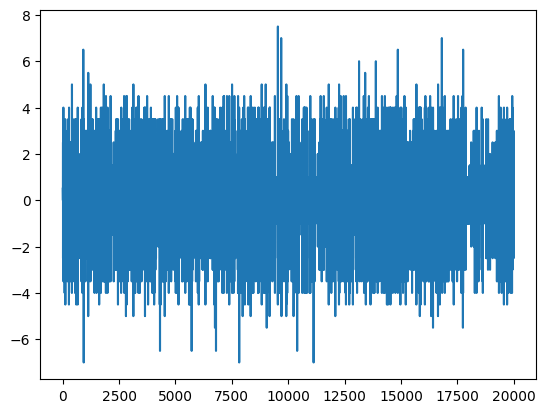

In [29]:
plt.plot(tomato_price_d1["mid_price"].diff())

In [30]:
tomato_price_d1.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='str')

In [31]:
tomato_vwap_d1 = tomato_price_d1[["bid_price_1", "bid_volume_1", "ask_price_1", "ask_volume_1"]].copy()

tomato_vwap_d1["vwap"] = (
    tomato_vwap_d1["bid_price_1"] * tomato_vwap_d1["bid_volume_1"] +
    tomato_vwap_d1["ask_price_1"] * tomato_vwap_d1["ask_volume_1"]
) / (
    tomato_vwap_d1["bid_volume_1"] + tomato_vwap_d1["ask_volume_1"]
)

# result
tomato_vwap_d1["vwap"]

0        5006.000000
3        5006.500000
5        5006.500000
6        5007.000000
8        5007.000000
            ...     
19990    4960.333333
19993    4959.363636
19994    4956.500000
19997    4957.500000
19998    4957.000000
Name: vwap, Length: 10000, dtype: float64

In [32]:
for i in range(20):
    print(f"autocorrelation for vwap lag {i} is {tomato_vwap_d1["vwap"].diff().autocorr(i)}")

autocorrelation for vwap lag 0 is 0.9999999999999999
autocorrelation for vwap lag 1 is -0.42931528856830314
autocorrelation for vwap lag 2 is -0.02029756715471203
autocorrelation for vwap lag 3 is 0.005132144349023453
autocorrelation for vwap lag 4 is -0.008705580889762204
autocorrelation for vwap lag 5 is 0.010574848225763255
autocorrelation for vwap lag 6 is -0.014553159133328705
autocorrelation for vwap lag 7 is 0.00830611023060829
autocorrelation for vwap lag 8 is -0.0067756176193035575
autocorrelation for vwap lag 9 is 0.008397297083283064
autocorrelation for vwap lag 10 is -0.0018439673760899846
autocorrelation for vwap lag 11 is -0.009846621904927869
autocorrelation for vwap lag 12 is 0.004594360002573369
autocorrelation for vwap lag 13 is 0.009762452606507401
autocorrelation for vwap lag 14 is -0.00736659027756025
autocorrelation for vwap lag 15 is -0.006614574877505682
autocorrelation for vwap lag 16 is 0.015043972479810614
autocorrelation for vwap lag 17 is -0.014337358009400

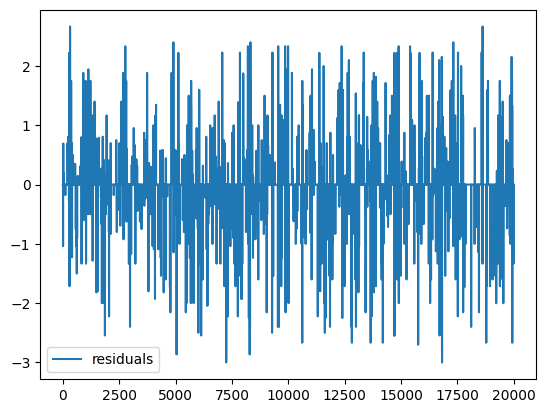

In [33]:
plt.figure()
plt.plot(1/2 * tomato_vwap_d1["ask_price_1"] + 1/2 * tomato_vwap_d1["bid_price_1"] - tomato_vwap_d1["vwap"], label="residuals")
plt.legend()
plt.show()

In [34]:
mask = ~tomato_price_d1["bid_price_3"].isna()
mask.value_counts()

bid_price_3
False    9633
True      367
Name: count, dtype: int64